# Oja's Rule — First Principal Component

This notebook implements **Oja's learning rule**, a single-neuron Hebbian model that converges to the first principal component (PC1) of a dataset.

We apply it to `europe.csv`, a dataset of 28 European countries described by 7 socioeconomic variables, and compare the result against scikit-learn's analytic PCA.

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 2. Load and preprocess the data

We keep only the 7 numerical features and drop the country name column.

**Standardization is mandatory** before running Oja's rule. Without it, variables measured in large units (e.g. `Area` in km²) would dominate the weight updates purely due to scale, not because they carry more variance. `StandardScaler` transforms each feature to mean 0 and standard deviation 1.

In [3]:
df = pd.read_csv("europe.csv")

feature_cols = [
    "Area",
    "GDP",
    "Inflation",
    "Life.expect",
    "Military",
    "Pop.growth",
    "Unemployment"
]

X_raw = df[feature_cols].values
countries = df["Country"].values

# Standardize: each column becomes mean=0, std=1
scaler = StandardScaler()
Z = scaler.fit_transform(X_raw)

print(f"Dataset shape: {Z.shape}  ({Z.shape[0]} countries, {Z.shape[1]} features)")

Dataset shape: (28, 7)  (28 countries, 7 features)


## 3. Oja's learning rule

The update rule for a single neuron is:

$$\Delta w = \eta \cdot y \cdot (x - y \cdot w)$$

where $y = x \cdot w$ is the neuron's output (the projection of the input onto the current weight vector).

- The term $\eta \cdot y \cdot x$ is the classic Hebbian update — strengthen the connection in the direction of the input.
- The term $-\eta \cdot y^2 \cdot w$ is the decay — it prevents the weights from growing unboundedly and is what makes Oja's rule converge to a unit-norm vector.

We also add explicit L2 normalization after each step to improve numerical stability.

**Key parameters:**
- `eta`: learning rate — controls how large each update step is
- `epochs`: number of full passes through the dataset
- `seed`: random seed for reproducibility (used for both weight initialization and sample shuffling)

In [4]:
def oja_rule(X, eta=0.001, epochs=100, seed=0):
    """
    Estimate the first principal component of X using Oja's learning rule.

    Parameters
    ----------
    X      : ndarray of shape (n_samples, n_features), must be standardized
    eta    : learning rate
    epochs : number of full passes over the data
    seed   : random seed for initialization and shuffling

    Returns
    -------
    w : unit-norm weight vector approximating PC1
    """
    rng = np.random.default_rng(seed)
    n_samples, n_features = X.shape

    # Initialize w as a random unit vector
    w = rng.standard_normal(n_features)
    w /= np.linalg.norm(w)

    for _ in range(epochs):
        # Shuffle sample order each epoch to avoid update order bias
        for i in rng.permutation(n_samples):
            x = X[i]
            y = x @ w                    # neuron output: scalar projection
            w += eta * y * (x - y * w)   # Oja update
            w /= np.linalg.norm(w)       # re-normalize to unit length

    return w

## 4. Train and compare against sklearn PCA

We run Oja's rule and compare the resulting weight vector `w_oja` against the first principal component returned by scikit-learn's `PCA`, which uses an analytic SVD decomposition.

**Sign alignment:** eigenvectors are only unique up to sign — both `w` and `-w` are valid representations of the same direction. We flip `w_oja` if it points opposite to `pc1` before computing similarity.

In [5]:
w_oja = oja_rule(Z, eta=0.001, epochs=100, seed=0)

# Analytic reference: sklearn PCA via SVD
pca = PCA(n_components=1)
pca.fit(Z)
pc1 = pca.components_[0]

# Align signs so the comparison is meaningful
if np.dot(w_oja, pc1) < 0:
    w_oja = -w_oja

# Cosine similarity — 1.0 means identical direction
cos_sim = np.dot(w_oja, pc1) / (np.linalg.norm(w_oja) * np.linalg.norm(pc1))

print(f"Cosine similarity between Oja and sklearn PC1: {cos_sim:.6f}")
print()
print(f"{'Feature':<15} {'Oja w':>10} {'sklearn PC1':>12}")
print("-" * 40)
for name, oj, sk in zip(feature_cols, w_oja, pc1):
    print(f"{name:<15} {oj:>10.4f} {sk:>12.4f}")

Cosine similarity between Oja and sklearn PC1: 0.999989

Feature              Oja w  sklearn PC1
----------------------------------------
Area               -0.1258      -0.1249
GDP                 0.4998       0.5005
Inflation          -0.4085      -0.4065
Life.expect         0.4831       0.4829
Military           -0.1860      -0.1881
Pop.growth          0.4735       0.4757
Unemployment       -0.2745      -0.2717


## 5. Interpret PC1 — Feature loadings

The loadings (components of `w_oja`) tell us how each original feature contributes to PC1.
- A **large positive** loading means the feature pushes a country's score up.
- A **large negative** loading means it pushes the score down.
- A loading **near zero** means the feature barely contributes to this component.

We sort by absolute value to immediately see which features dominate.

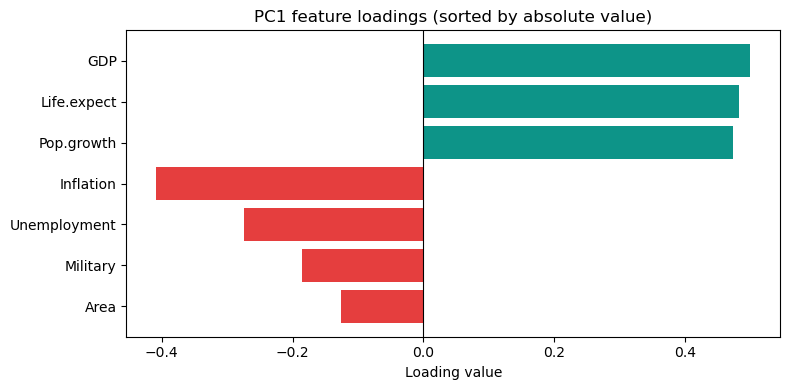

GDP             0.499807
Life.expect     0.483080
Pop.growth      0.473514
Inflation      -0.408476
Unemployment   -0.274481
Military       -0.185996
Area           -0.125795


In [6]:
loadings = pd.Series(w_oja, index=feature_cols).sort_values(key=abs, ascending=False)

colors = ["#0D9488" if v >= 0 else "#E53E3E" for v in loadings]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(loadings.index, loadings.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Loading value")
ax.set_title("PC1 feature loadings (sorted by absolute value)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(loadings.to_string())

**Reading the loadings:**

The two strongest positive contributors are `Life.expect` and `GDP` — wealthy, long-lived nations score high. The two strongest negative contributors are `Inflation` and `Unemployment` — economically stressed nations score low. `Area` is near zero, meaning geographic size is unrelated to this component.

**PC1 can be interpreted as a socioeconomic prosperity axis.**

## 7. Project countries onto PC1

We compute each country's score by projecting its standardized feature vector onto `w_oja`. This gives a single number per country that ranks them along the prosperity axis.

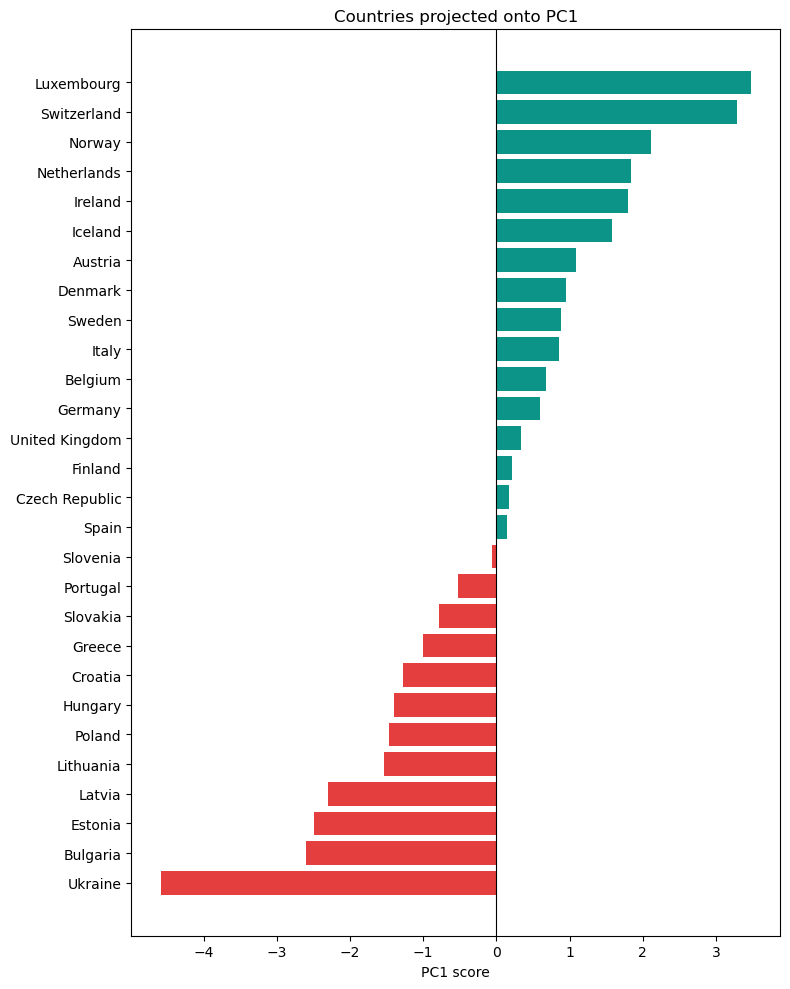

       Country  PC1_score
       Ukraine  -4.584787
      Bulgaria  -2.603239
       Estonia  -2.486268
        Latvia  -2.306538
     Lithuania  -1.533653
        Poland  -1.473234
       Hungary  -1.395775
       Croatia  -1.269256
        Greece  -0.996918
      Slovakia  -0.786167
      Portugal  -0.526250
      Slovenia  -0.063946
         Spain   0.151764
Czech Republic   0.170694
       Finland   0.212106
United Kingdom   0.340778
       Germany   0.595881
       Belgium   0.682554
         Italy   0.853694
        Sweden   0.884722
       Denmark   0.957437
       Austria   1.083370
       Iceland   1.577802
       Ireland   1.801165
   Netherlands   1.843835
        Norway   2.111537
   Switzerland   3.285542
    Luxembourg   3.473151


In [7]:
# Matrix multiplication: (28 x 7) @ (7,) -> (28,)
scores = Z @ w_oja

df_scores = pd.DataFrame({"Country": countries, "PC1_score": scores})
df_scores = df_scores.sort_values("PC1_score", ascending=True).reset_index(drop=True)

# Color bars by sign: positive = prosperous (teal), negative = stressed (red)
bar_colors = ["#0D9488" if s >= 0 else "#E53E3E" for s in df_scores["PC1_score"]]

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(df_scores["Country"], df_scores["PC1_score"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("PC1 score")
ax.set_title("Countries projected onto PC1")
plt.tight_layout()
plt.show()

print(df_scores.to_string(index=False))

**Observation:** The ranking is coherent with the loading interpretation: countries with stronger GDP/life expectancy and lower inflation/unemployment tend to score higher, while countries with weaker economic indicators tend to score lower. The model used no geographic variables.